# Esplorazione del dataset NASA C-MAPSS

Questo notebook descrive i dati su cui si basa il progetto e documenta le
proprietà che ne determinano l'impostazione sperimentale.

## Dati analizzati

Il dataset NASA C-MAPSS (Turbofan Engine Degradation Simulation) raccoglie
letture di sensori di motori aeronautici simulati, seguiti dal funzionamento
normale fino al guasto. È distribuito dal NASA Prognostics Data Repository ed è
composto da quattro sottoinsiemi indipendenti, FD001, FD002, FD003 e FD004, che
si distinguono per il numero di regimi di volo simulati e per il numero di modi
di guasto presenti.

Ogni riga è un ciclo di funzionamento di un motore e contiene 26 valori:
identificativo dell'unità, numero di ciclo, tre impostazioni operative (quota,
numero di Mach, angolo della manetta) e ventuno letture di sensori. Nei file di
training ogni traiettoria arriva al guasto; nei file di test è troncata prima.

Il compito del progetto è predire la vita utile residua di un motore, cioè il
numero di cicli che mancano al guasto, a partire dalle letture di un ciclo.

## Cosa legge questo notebook

Il notebook non apre i file grezzi e non esegue calcoli pesanti. Legge gli
aggregati salvati in `experiments/exploration/`, prodotti da:

    python -m scripts.run_exploration

che a sua volta si appoggia a `src/data.py` per il caricamento e a
`src/explore.py` per le statistiche. I file grezzi non sono versionati e vanno
collocati in `data/raw/` secondo le istruzioni del README.

## Cosa produce

Le figure in `results/figures/` e la tabella riassuntiva dei quattro
sottoinsiemi in `results/tables/`. Entrambe sono versionate: sono la traccia
verificabile di ciò che è stato osservato.

## Cosa il notebook non fa

Non seleziona variabili. Le correlazioni con il target riportate più avanti sono
calcolate sull'intero insieme di addestramento: usarle per scartare variabili
significherebbe scegliere guardando anche le porzioni di dati su cui poi si
misura il risultato. La selezione delle variabili avviene dentro il flusso di
validazione, nella fase sperimentale. Fa eccezione la rimozione delle variabili
costanti, che è una proprietà strutturale della variabile e non una relazione
con il target.

## Preparazione

Il notebook risiede in `notebooks/` mentre i moduli del progetto stanno in
`src/`: la prima cella inserisce la radice della repository nel percorso di
ricerca di Python, in modo che il notebook sia eseguibile senza variabili
d'ambiente.

In [38]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.data import SENSOR_COLS, SETTING_COLS
from src.target import RUL_CAP

EXPLORATION_DIR = ROOT / "experiments" / "exploration"
FIGURES_DIR = ROOT / "results" / "figures"
TABLES_DIR = ROOT / "results" / "tables"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

SUBSET_ORDER = ["FD001", "FD002", "FD003", "FD004"]
IN_SCOPE = ["FD001", "FD003"]


def load(name):
    path = EXPLORATION_DIR / f"{name}.csv"
    if not path.exists():
        raise FileNotFoundError(
            f"{path} non trovato. Eseguire prima: python -m scripts.run_exploration"
        )
    return pd.read_csv(path)


def save_figure(fig, name):
    path = FIGURES_DIR / f"{name}.png"
    fig.savefig(path, bbox_inches="tight")
    print(f"figura salvata: {path.relative_to(ROOT)}")


lengths = load("trajectory_lengths")
conditions = load("operating_conditions")
summary = load("variable_summary")
summary_by_condition = load("variable_summary_by_condition")
correlations = load("target_correlations")
correlations_by_phase = load("target_correlations_by_phase")
correlation_matrix = load("variable_correlation_matrix")
traces = load("sensor_traces")

print({name: len(table) for name, table in [
    ("trajectory_lengths", lengths),
    ("operating_conditions", conditions),
    ("variable_summary", summary),
    ("variable_summary_by_condition", summary_by_condition),
    ("target_correlations", correlations),
    ("target_correlations_by_phase", correlations_by_phase),
    ("variable_correlation_matrix", correlation_matrix),
    ("sensor_traces", traces),
]})

{'trajectory_lengths': 1416, 'operating_conditions': 14, 'variable_summary': 96, 'variable_summary_by_condition': 336, 'target_correlations': 96, 'target_correlations_by_phase': 192, 'variable_correlation_matrix': 1764, 'sensor_traces': 4742}


## Durata delle traiettorie

La durata di una traiettoria di training è il numero di cicli che il motore ha
funzionato prima del guasto, e coincide con la vita utile residua al primo
ciclo. La sua distribuzione dice due cose: quanto sono eterogenei i motori di
una stessa popolazione, e quale intervallo di valori il target dovrà coprire.

La durata delle traiettorie di test è invece la lunghezza della porzione
osservata prima del troncamento, e non è una durata di vita.

In [39]:
train_lengths = lengths[lengths["split"] == "train"]
test_lengths = lengths[lengths["split"] == "test"]

durations = (
    train_lengths.groupby("subset")["length"]
    .agg(motori="count", minimo="min", mediana="median", media="mean",
         massimo="max", deviazione="std")
    .round(1)
    .loc[SUBSET_ORDER]
)
durations

,motori,minimo,mediana,media,massimo,deviazione
subset,,,,,,
FD001,100,128,199.0,206.3,362,46.3
FD002,260,128,199.0,206.8,378,46.8
FD003,100,145,220.5,247.2,525,86.5
FD004,249,128,234.0,246.0,543,73.1


figura salvata: results/figures/durate_traiettorie.png


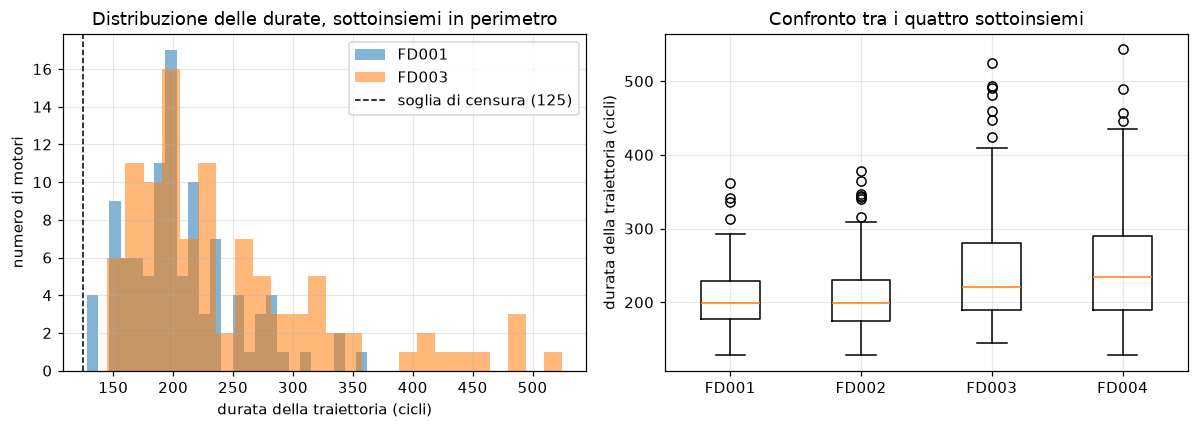

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for name in IN_SCOPE:
    values = train_lengths.loc[train_lengths["subset"] == name, "length"]
    axes[0].hist(values, bins=25, alpha=0.55, label=name)
axes[0].axvline(RUL_CAP, color="black", linestyle="--", linewidth=1,
                label=f"soglia di censura ({RUL_CAP})")
axes[0].set_xlabel("durata della traiettoria (cicli)")
axes[0].set_ylabel("numero di motori")
axes[0].set_title("Distribuzione delle durate, sottoinsiemi in perimetro")
axes[0].legend()

axes[1].boxplot(
    [train_lengths.loc[train_lengths["subset"] == n, "length"] for n in SUBSET_ORDER],
    tick_labels=SUBSET_ORDER,
)
axes[1].set_ylabel("durata della traiettoria (cicli)")
axes[1].set_title("Confronto tra i quattro sottoinsiemi")

fig.tight_layout()
save_figure(fig, "durate_traiettorie")
plt.show()

FD001 e FD002 hanno distribuzioni delle durate praticamente sovrapposte (mediana
199 cicli in entrambi, deviazione standard 46). FD003 e FD004 hanno traiettorie
più lunghe e più disperse (mediana 220 e 234, deviazione 87 e 73), coerentemente
con la presenza di due modi di guasto invece di uno.

La traiettoria più breve dura 128 cicli in FD001 e 145 in FD003: entrambe
superiori alla soglia di censura del target, che è quindi attraversata da ogni
motore.

## Regimi di funzionamento

Le tre impostazioni operative descrivono la condizione di volo. Non assumono
valori continui ma oscillano con rumore attorno a poche terne nominali:
arrotondandole si ottengono i regimi distinti effettivamente simulati.

Il numero di regimi è la differenza strutturale più importante tra i
sottoinsiemi, perché determina se le letture di due cicli qualsiasi siano
confrontabili tra loro.

In [41]:
regimes = (
    conditions.groupby("subset")
    .size()
    .rename("regimi distinti")
    .loc[SUBSET_ORDER]
    .to_frame()
)
display(regimes)

conditions.sort_values(["subset", "n_rows"], ascending=[True, False])

,regimi distinti
subset,
FD001,1
FD002,6
FD003,1
FD004,6


,subset,setting_1,setting_2,setting_3,condition,n_rows,n_units
0,FD001,0.0,0.00,100.0,0.0 | 0.0 | 100.0,20631,100
1,FD002,42.0,0.84,100.0,42.0 | 0.84 | 100.0,13458,260
2,FD002,20.0,0.70,100.0,20.0 | 0.7 | 100.0,8122,260
3,FD002,10.0,0.25,100.0,10.0 | 0.25 | 100.0,8096,260
4,FD002,0.0,0.00,100.0,0.0 | 0.0 | 100.0,8044,260
5,FD002,35.0,0.84,100.0,35.0 | 0.84 | 100.0,8037,260
6,FD002,25.0,0.62,60.0,25.0 | 0.62 | 60.0,8002,260
7,FD003,0.0,0.00,100.0,0.0 | 0.0 | 100.0,24720,100
8,FD004,42.0,0.84,100.0,42.0 | 0.84 | 100.0,15395,249
9,FD004,0.0,0.00,100.0,0.0 | 0.0 | 100.0,9238,249


figura salvata: results/figures/regimi_funzionamento.png


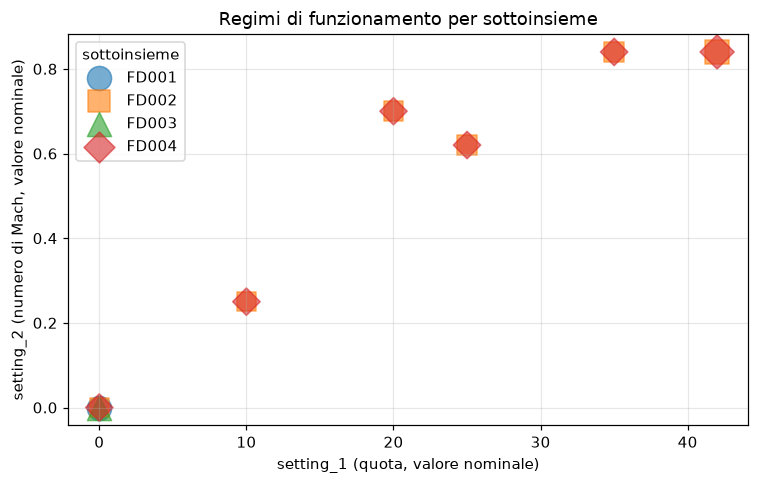

In [42]:
fig, ax = plt.subplots(figsize=(7, 4.5))

markers = {"FD001": "o", "FD002": "s", "FD003": "^", "FD004": "D"}
for name in SUBSET_ORDER:
    block = conditions[conditions["subset"] == name]
    ax.scatter(
        block["setting_1"], block["setting_2"],
        s=block["n_rows"] / block["n_rows"].max() * 220 + 30,
        marker=markers[name], alpha=0.6, label=name,
    )

ax.set_xlabel("setting_1 (quota, valore nominale)")
ax.set_ylabel("setting_2 (numero di Mach, valore nominale)")
ax.set_title("Regimi di funzionamento per sottoinsieme")
ax.legend(title="sottoinsieme")

fig.tight_layout()
save_figure(fig, "regimi_funzionamento")
plt.show()

FD001 e FD003 hanno un unico regime, corrispondente al livello del mare. FD002 e
FD004 ne hanno sei, distribuiti su quote e numeri di Mach diversi. La dimensione
dei simboli è proporzionale al numero di cicli osservati in ciascun regime.

## Variabili costanti

Una variabile che assume un solo valore su tutto l'insieme di addestramento non
porta informazione e va rimossa. La verifica usa il numero di valori distinti e
non la deviazione standard, che su una colonna di valori identici non risulta
esattamente nulla per effetto dell'aritmetica in virgola mobile.

Accanto alle costanti sono elencate le variabili con pochi valori distinti: sono
variabili discrete, non degeneri, e la distinzione conta perché le prime si
scartano e le seconde no.

In [43]:
constant_by_subset = {
    name: sorted(summary.loc[(summary["subset"] == name) & summary["constant"], "variable"])
    for name in SUBSET_ORDER
}
for name, variables in constant_by_subset.items():
    print(f"{name}: {len(variables)} costanti -> {', '.join(variables) if variables else 'nessuna'}")

in_scope_constant = sorted(set(constant_by_subset["FD001"]) & set(constant_by_subset["FD003"]))
print(f"\nCostanti in entrambi i sottoinsiemi in perimetro: {len(in_scope_constant)}")
print(", ".join(in_scope_constant))

FD001: 7 costanti -> sensor_01, sensor_05, sensor_10, sensor_16, sensor_18, sensor_19, setting_3
FD002: 0 costanti -> nessuna
FD003: 6 costanti -> sensor_01, sensor_05, sensor_16, sensor_18, sensor_19, setting_3
FD004: 0 costanti -> nessuna

Costanti in entrambi i sottoinsiemi in perimetro: 6
sensor_01, sensor_05, sensor_16, sensor_18, sensor_19, setting_3


In [44]:
few_values = summary[(summary["n_unique"] < 10) & (~summary["constant"])]
few_values[["subset", "variable", "n_unique", "min", "max"]].sort_values(
    ["subset", "variable"]
)

,subset,variable,n_unique,min,max
8,FD001,sensor_06,2,21.60,21.61
27,FD002,sensor_01,6,445.00,518.67
31,FD002,sensor_05,6,3.91,14.62
36,FD002,sensor_10,9,0.93,1.30
42,FD002,sensor_16,2,0.02,0.03
44,FD002,sensor_18,6,1915.00,2388.00
45,FD002,sensor_19,2,84.93,100.00
26,FD002,setting_3,2,60.00,100.00
60,FD003,sensor_10,4,1.29,1.32
75,FD004,sensor_01,6,445.00,518.67


Su FD001 sono costanti sette variabili, su FD003 sei: l'intersezione, cioè
l'insieme rimovibile su entrambi i sottoinsiemi in perimetro, comprende
`setting_3` e i sensori 01, 05, 16, 18 e 19. Il sensore 10 è costante su FD001
ma assume quattro valori su FD003, quindi non appartiene all'intersezione.

Su FD002 e FD004 nessuna variabile risulta costante. Non è un segno di maggiore
informatività: gli stessi sensori che a regime singolo sono piatti variano al
variare della condizione di volo, e la variazione osservata è dovuta al regime e
non al degrado. La sezione seguente misura questo effetto.

## Effetto dei regimi sulla variabilità dei sensori

Per ogni sensore si confronta la variabilità complessiva con la variabilità
media misurata dentro un singolo regime. Il rapporto tra le due dice quanta
parte della variabilità osservata sopravvive una volta fissata la condizione di
volo: un rapporto vicino a zero significa che il sensore varia quasi
esclusivamente perché cambia il regime.

In [45]:
def variability_ratio(subset_name):
    within = (
        summary_by_condition[summary_by_condition["subset"] == subset_name]
        .groupby("variable")["std"]
        .mean()
        .rename("std_entro_regime")
    )
    overall = (
        summary[summary["subset"] == subset_name]
        .set_index("variable")["std"]
        .rename("std_complessiva")
    )
    table = pd.concat([overall, within], axis=1).loc[SENSOR_COLS]
    table["rapporto"] = table["std_entro_regime"] / table["std_complessiva"]
    return table.sort_values("rapporto")


ratio_fd002 = variability_ratio("FD002")
ratio_fd001 = variability_ratio("FD001")
ratio_fd002.round(4)

,std_complessiva,std_entro_regime,rapporto
variable,,,
sensor_18,145.3280,0.0000,0.0000
sensor_19,5.3641,0.0000,0.0000
sensor_05,3.6138,0.0000,0.0000
sensor_01,26.3897,0.0000,0.0000
sensor_06,5.4318,0.0036,0.0007
sensor_08,145.2098,0.1888,0.0013
sensor_13,128.0683,0.1997,0.0016
sensor_12,137.6595,0.4712,0.0034
sensor_07,146.0053,0.5848,0.0040


figura salvata: results/figures/variabilita_entro_regime.png


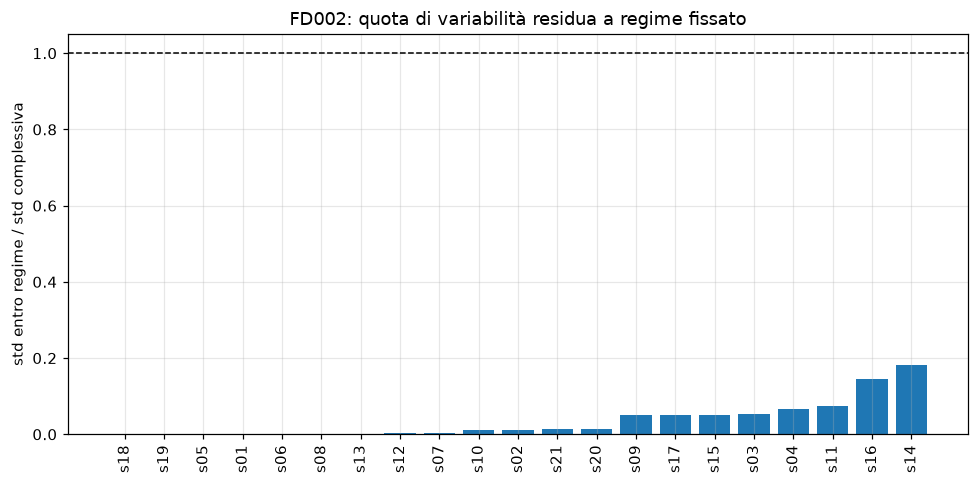

In [46]:
fig, ax = plt.subplots(figsize=(9, 4.5))

ordered = ratio_fd002.dropna(subset=["rapporto"]).sort_values("rapporto")
ax.bar(range(len(ordered)), ordered["rapporto"], color="tab:blue")
ax.set_xticks(range(len(ordered)))
ax.set_xticklabels([c.replace("sensor_", "s") for c in ordered.index], rotation=90)
ax.axhline(1.0, color="black", linewidth=1, linestyle="--")
ax.set_ylabel("std entro regime / std complessiva")
ax.set_title("FD002: quota di variabilità residua a regime fissato")

fig.tight_layout()
save_figure(fig, "variabilita_entro_regime")
plt.show()

Su FD002 il rapporto non supera 0,18 per alcun sensore e per la maggior parte
delle variabili resta sotto 0,06: fissata la condizione di volo, la variabilità
delle letture quasi scompare. Ne segue che la variabilità osservata accorpando i
sei regimi è dovuta al regime e non al degrado.

Su FD001 il rapporto vale esattamente 1 per ogni variabile, perché con un solo
regime la variabilità entro regime coincide con quella complessiva. Il valore
serve come controllo del calcolo, non come risultato.

## Correlazione delle variabili con il target

La correlazione di Pearson misura la componente lineare della relazione tra una
variabile e la vita utile residua; quella di Spearman coglie una relazione
monotona anche non lineare. Il confronto tra le due indica dove una relazione
esiste ma non è lineare, ed è un'informazione che riguarda direttamente il
confronto tra modelli lineari e modelli che non lo sono.

Le correlazioni sono calcolate accorpando le righe di tutte le unità, quindi
ignorano il raggruppamento per motore e vanno lette come indicazione di
massima. Non sono usate per selezionare variabili.

In [47]:
top_correlations = (
    correlations.dropna(subset=["pearson"])
    .sort_values(["subset", "abs_pearson"], ascending=[True, False])
    .groupby("subset")
    .head(8)
)
top_correlations[["subset", "variable", "pearson", "spearman"]].round(3)

,subset,variable,pearson,spearman
13,FD001,sensor_11,-0.696,-0.718
6,FD001,sensor_04,-0.679,-0.702
14,FD001,sensor_12,0.672,0.693
9,FD001,sensor_07,0.657,0.679
17,FD001,sensor_15,-0.643,-0.666
23,FD001,sensor_21,0.636,0.657
22,FD001,sensor_20,0.629,0.653
4,FD001,sensor_02,-0.606,-0.629
42,FD002,sensor_16,-0.071,-0.078
37,FD002,sensor_11,-0.047,-0.170


figura salvata: results/figures/correlazioni_target.png


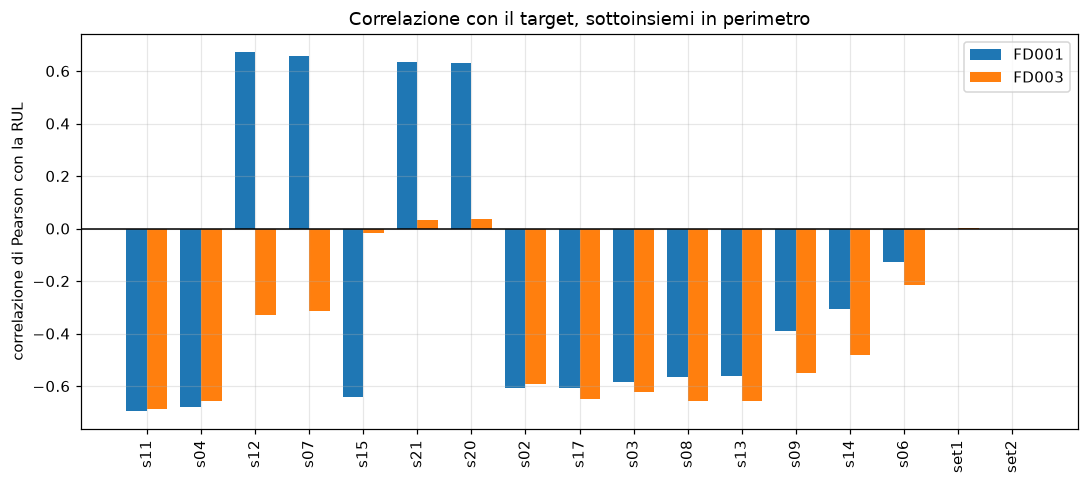

In [48]:
fig, ax = plt.subplots(figsize=(10, 4.5))

reference = (
    correlations[(correlations["subset"] == "FD001")]
    .dropna(subset=["pearson"])
    .sort_values("abs_pearson", ascending=False)
)
order = reference["variable"].tolist()
width = 0.38

for offset, name in zip((-width / 2, width / 2), IN_SCOPE):
    block = correlations[correlations["subset"] == name].set_index("variable")
    values = block.reindex(order)["pearson"]
    ax.bar(np.arange(len(order)) + offset, values, width=width, label=name)

ax.set_xticks(np.arange(len(order)))
ax.set_xticklabels([c.replace("sensor_", "s").replace("setting_", "set") for c in order],
                   rotation=90)
ax.axhline(0, color="black", linewidth=1)
ax.set_ylabel("correlazione di Pearson con la RUL")
ax.set_title("Correlazione con il target, sottoinsiemi in perimetro")
ax.legend()

fig.tight_layout()
save_figure(fig, "correlazioni_target")
plt.show()

In [49]:
max_correlation = (
    correlations.dropna(subset=["pearson"])
    .groupby("subset")["abs_pearson"]
    .max()
    .loc[SUBSET_ORDER]
    .round(3)
    .rename("max |pearson|")
    .to_frame()
)
max_correlation["max |spearman|"] = (
    correlations.dropna(subset=["spearman"])
    .assign(abs_spearman=lambda d: d["spearman"].abs())
    .groupby("subset")["abs_spearman"]
    .max()
    .round(3)
)
max_correlation

,max |pearson|,max |spearman|
subset,,
FD001,0.696,0.718
FD002,0.071,0.247
FD003,0.689,0.758
FD004,0.078,0.401


Su FD001 e FD003 la correlazione massima in valore assoluto raggiunge circa
0,70; su FD002 e FD004 non supera 0,08. Il segnale non è assente nei
sottoinsiemi a regimi multipli: accorpando sei regimi, la variabilità dovuta
alla condizione di volo domina quella dovuta al degrado e la correlazione
marginale si annulla. Lo conferma il fatto che su FD002 e FD004 la correlazione
di Spearman resta sensibilmente maggiore di quella di Pearson.

Rendere utilizzabili FD002 e FD004 richiede quindi uno stadio di normalizzazione
dei sensori dentro ciascun regime. Il perimetro sperimentale del progetto è
limitato a FD001 e FD003, che condividono il regime singolo e differiscono per
il numero di modi di guasto: questo tiene ferma una variabile e ne fa variare
una sola, e mantiene identico il pre-processing sui due sottoinsiemi.

## Correlazione tra sensori

Sensori che misurano grandezze legate dallo stesso processo fisico tendono a
muoversi insieme. Un'elevata correlazione tra variabili esplicative rende
instabili le stime dei coefficienti nei modelli lineari non regolarizzati, ed è
la situazione in cui la regolarizzazione e la riduzione della dimensionalità
hanno un ruolo.

figura salvata: results/figures/correlazione_sensori.png


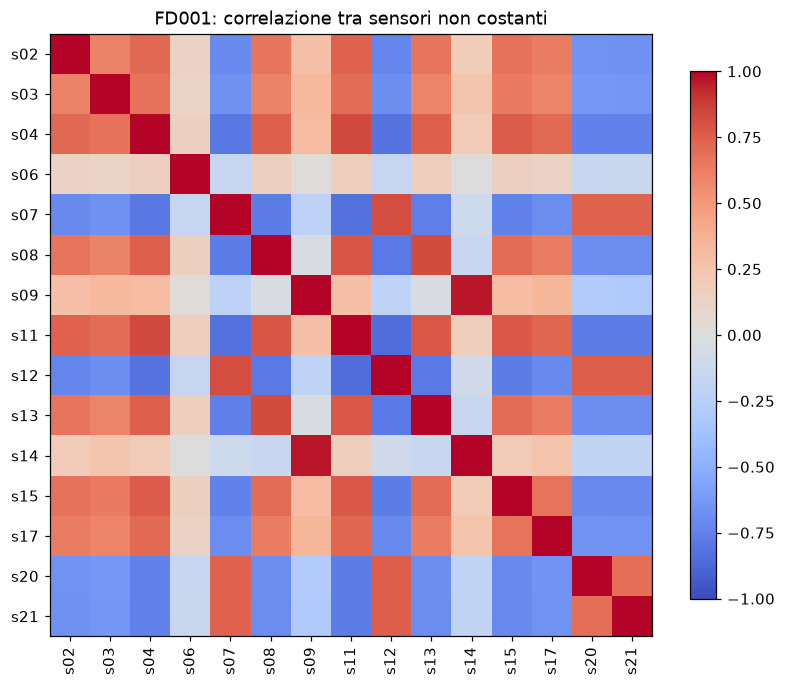

In [50]:
def correlation_grid(subset_name):
    block = correlation_matrix[correlation_matrix["subset"] == subset_name]
    grid = block.pivot(index="variable_a", columns="variable_b", values="pearson")
    varying = grid.dropna(how="all").dropna(axis=1, how="all").columns.tolist()
    return grid.loc[varying, varying]


grid_fd001 = correlation_grid("FD001")

fig, ax = plt.subplots(figsize=(7.5, 6.5))
image = ax.imshow(grid_fd001.values, cmap="coolwarm", vmin=-1, vmax=1)
labels = [c.replace("sensor_", "s") for c in grid_fd001.columns]
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=90)
ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels)
ax.set_title("FD001: correlazione tra sensori non costanti")
ax.grid(False)
fig.colorbar(image, ax=ax, shrink=0.8)

fig.tight_layout()
save_figure(fig, "correlazione_sensori")
plt.show()

In [51]:
def strong_pairs(subset_name, threshold=0.9):
    grid = correlation_grid(subset_name)
    values = grid.where(np.triu(np.ones(grid.shape), k=1).astype(bool)).stack()
    strong = values[values.abs() > threshold].sort_values(key=abs, ascending=False)
    return strong


for name in IN_SCOPE:
    pairs = strong_pairs(name)
    grid = correlation_grid(name)
    total = len(grid.columns) * (len(grid.columns) - 1) // 2
    print(f"{name}: {len(pairs)} coppie su {total} con |r| > 0.9")

strong_pairs("FD001").round(3).head(15)

FD001: 1 coppie su 105 con |r| > 0.9
FD003: 3 coppie su 120 con |r| > 0.9


variable_a  variable_b
sensor_09   sensor_14     0.963
dtype: float64

La ridondanza tra sensori risulta limitata: su FD001 una sola coppia su 105
supera 0,9 in valore assoluto (`sensor_09` e `sensor_14`, 0,963), su FD003 tre
coppie su 120. La struttura di correlazione mostra blocchi di variabili che si
muovono insieme, ma non un insieme di misure sostanzialmente duplicate.

La conseguenza riguarda il modo in cui vanno letti i risultati dei modelli
regolarizzati e della regressione sulle componenti principali. Su questi dati
la loro eventuale utilità non si spiega con la collinearità tra le variabili
esplicative, che è modesta, ma con il rapporto tra il numero di variabili e il
numero di unità indipendenti disponibili: le righe sono decine di migliaia, ma i
motori sono cento, e la numerosità campionaria rilevante è la seconda.

## Andamento dei sensori lungo la vita di un motore

Le letture dei sensori delle prime cinque unità di FD001, riportate in funzione
della vita utile residua, mostrano la forma della degradazione. L'asse orizzontale
è orientato in modo che il tempo scorra da sinistra a destra e il guasto si trovi
a destra.

figura salvata: results/figures/tracce_sensori.png


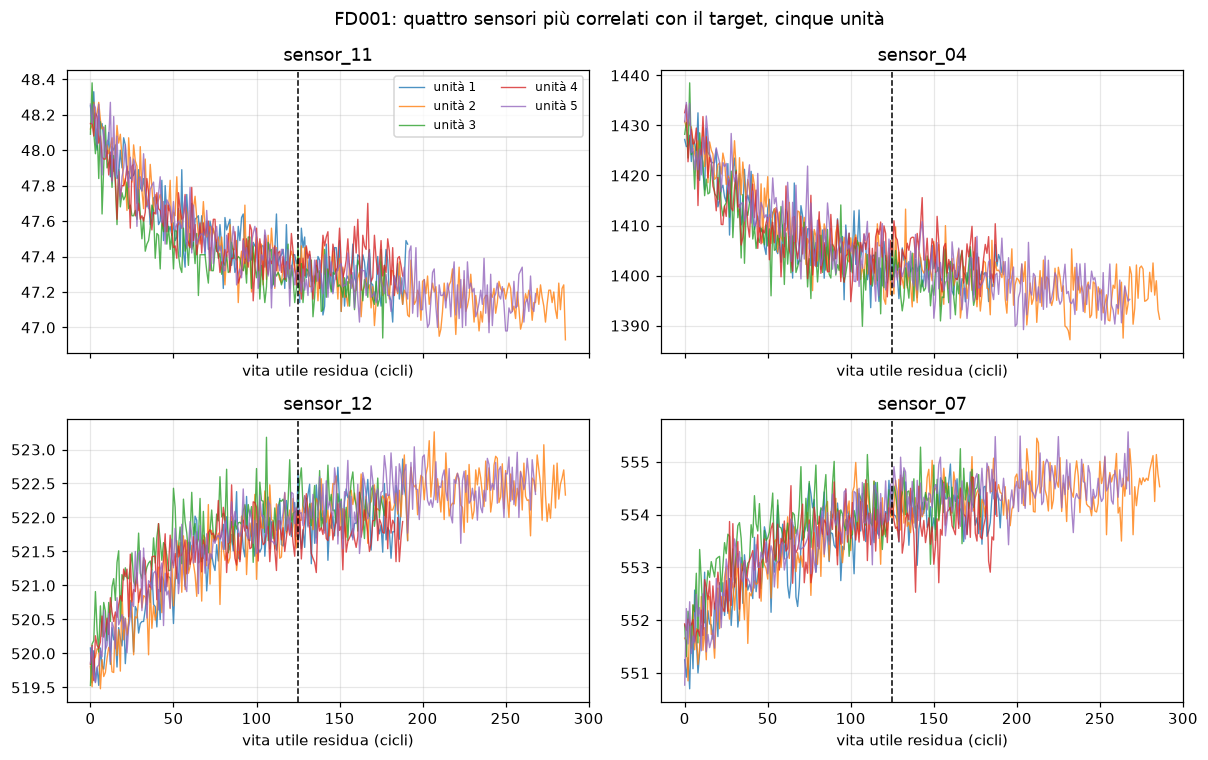

In [52]:
subset_traces = traces[traces["subset"] == "FD001"]
top_sensors = (
    correlations[correlations["subset"] == "FD001"]
    .dropna(subset=["pearson"])
    .sort_values("abs_pearson", ascending=False)
    .head(4)["variable"]
    .tolist()
)

fig, axes = plt.subplots(2, 2, figsize=(11, 7), sharex=True)
for ax, sensor in zip(axes.ravel(), top_sensors):
    for unit, group in subset_traces.groupby("unit"):
        ax.plot(group["rul"], group[sensor], linewidth=0.9, alpha=0.8, label=f"unità {unit}")
    ax.invert_xaxis()
    ax.axvline(RUL_CAP, color="black", linestyle="--", linewidth=1)
    ax.set_title(sensor)
    ax.set_xlabel("vita utile residua (cicli)")

axes[0, 0].legend(fontsize=8, ncol=2)
fig.suptitle("FD001: quattro sensori più correlati con il target, cinque unità")
fig.tight_layout()
save_figure(fig, "tracce_sensori")
plt.show()

Le letture di un singolo ciclo sono rumorose: l'andamento della degradazione non
è leggibile da un ciclo isolato ma emerge come deriva su molti cicli. La linea
verticale tratteggiata segna la soglia di censura del target. La sezione seguente
misura in modo quantitativo ciò che questa figura mostra qualitativamente.

## Informatività dei sensori nelle due fasi di vita

La censura del target poggia su un'assunzione precisa: nella prima parte della
vita di un motore il degrado non è ancora osservabile, cioè le letture dei
sensori non variano al variare della vita residua. L'assunzione è verificabile
calcolando la correlazione tra sensore e vita utile residua separatamente sulle
righe con residuo superiore alla soglia e su quelle con residuo inferiore.

Se sopra soglia la correlazione è prossima a zero e sotto soglia è marcata,
l'assunzione regge. Se i due valori sono simili, la censura sta scartando
informazione utile.

In [53]:
PHASES = ["oltre_soglia", "entro_soglia"]

phase_pivot = correlations_by_phase.pivot_table(
    index=["subset", "variable"], columns="phase", values="pearson"
)
# Reindicizzazione esplicita delle colonne: se in un sottoinsieme una delle due
# fasi non contenesse righe utilizzabili, la colonna corrispondente mancherebbe e
# le celle successive fallirebbero invece di riportare un valore mancante.
phase_pivot = phase_pivot.reindex(columns=PHASES).reset_index()
reference_order = (
    correlations.dropna(subset=["pearson"])
    .sort_values(["subset", "abs_pearson"], ascending=[True, False])
    .groupby("subset")
    .head(8)[["subset", "variable", "abs_pearson"]]
)
phase_table = reference_order.merge(phase_pivot, on=["subset", "variable"])
phase_table[phase_table["subset"].isin(IN_SCOPE)][
    ["subset", "variable", "oltre_soglia", "entro_soglia"]
].round(3)

,subset,variable,oltre_soglia,entro_soglia
0,FD001,sensor_11,-0.171,-0.765
1,FD001,sensor_04,-0.157,-0.741
2,FD001,sensor_12,0.159,0.737
3,FD001,sensor_07,0.143,0.720
4,FD001,sensor_15,-0.137,-0.712
5,FD001,sensor_21,0.144,0.696
6,FD001,sensor_20,0.123,0.690
7,FD001,sensor_02,-0.131,-0.671
16,FD003,sensor_11,-0.325,-0.779
17,FD003,sensor_04,-0.282,-0.735


figura salvata: results/figures/correlazioni_per_fase.png


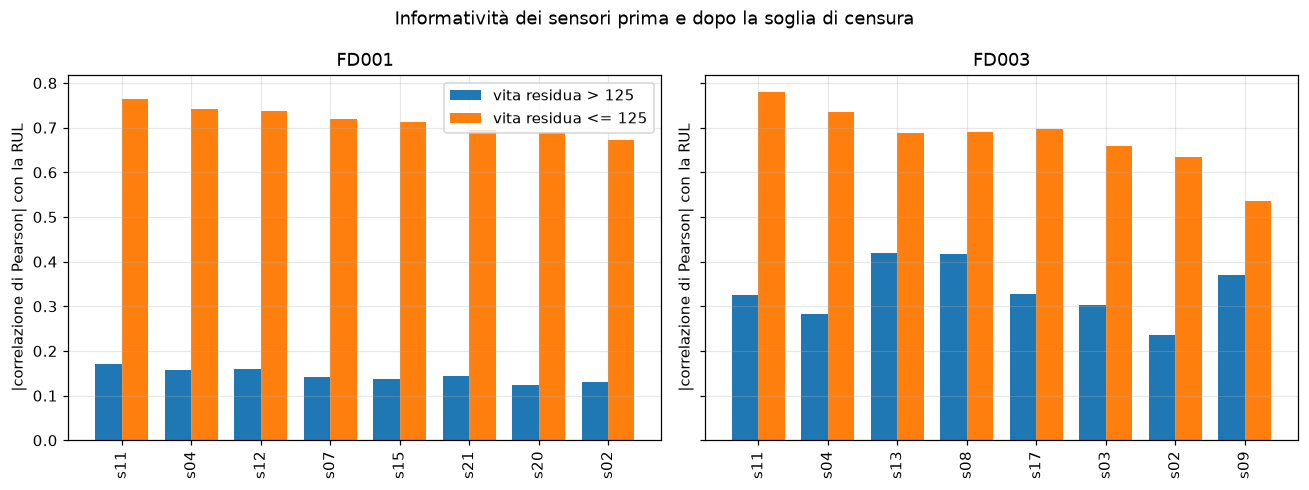

In [54]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)

for ax, name in zip(axes, IN_SCOPE):
    block = phase_table[phase_table["subset"] == name]
    positions = np.arange(len(block))
    ax.bar(positions - 0.19, block["oltre_soglia"].abs(), width=0.38,
           label=f"vita residua > {RUL_CAP}")
    ax.bar(positions + 0.19, block["entro_soglia"].abs(), width=0.38,
           label=f"vita residua <= {RUL_CAP}")
    ax.set_xticks(positions)
    ax.set_xticklabels([c.replace("sensor_", "s") for c in block["variable"]], rotation=90)
    ax.set_title(name)
    ax.set_ylabel("|correlazione di Pearson| con la RUL")

axes[0].legend()
fig.suptitle("Informatività dei sensori prima e dopo la soglia di censura")
fig.tight_layout()
save_figure(fig, "correlazioni_per_fase")
plt.show()

Su FD001 la separazione è netta: sopra soglia le correlazioni restano tra 0,14 e
0,17 in valore assoluto, sotto soglia salgono a 0,71-0,77. Nella prima fase di
vita i sensori non indicano quanto manca al guasto; nella seconda lo indicano
con chiarezza. La censura del target è quindi coerente con la struttura del dato
e non solo con una convenzione di letteratura.

Su FD003 la separazione esiste ma è meno pronunciata: sopra soglia le
correlazioni raggiungono 0,42 per `sensor_13` e `sensor_08` e 0,32-0,33 per
`sensor_11` e `sensor_17`, contro valori tra 0,69 e 0,78 sotto soglia. Una parte
di informazione utile è quindi presente già prima della soglia, e la censura la
scarta. La lettura plausibile è che con due modi di guasto una parte della
popolazione inizi a degradare più precocemente, ma resta un'interpretazione.

Questo è un limite dichiarato del target adottato, e riguarda FD003 più di
FD001. La soglia non viene modificata: è stata fissata prima di questa misura, e
cambiarla ora sarebbe una scelta fatta guardando il risultato. La sua influenza
sulle conclusioni viene invece quantificata rieseguendo, a fine lavoro, il
modello migliore e la baseline lineare regolarizzata anche con target non
censurato.

Su FD002 e FD004 le correlazioni sopra soglia sono nulle e sotto soglia
raggiungono appena 0,10: conferma indipendente che in quei sottoinsiemi il
segnale è schiacciato dal regime operativo in entrambe le fasi di vita, e non
dalla fase di vita.

## Il target e la censura a soglia

La vita utile residua di una traiettoria di training si ottiene per differenza
tra il ciclo del guasto e il ciclo corrente, e decresce linearmente da un valore
pari alla durata della traiettoria fino a zero.

Su questa definizione il progetto applica una censura: il target resta costante
al valore di soglia finché la vita residua è superiore, e decresce linearmente
dopo. La ragione è visibile nei tracciati della sezione precedente: nella prima
parte della vita le letture non mostrano degradazione, e due motori con vite
residue molto diverse presentano in quella fase letture indistinguibili. Un
target lineare chiederebbe di predire valori diversi a partire da ingressi
uguali, aggiungendo alla metrica una componente che nessun modello può ridurre e
che pesa in modo sproporzionato in una misura quadratica perché ricade sui valori
più grandi.

La soglia adottata è di 125 cicli, inferiore alla durata della traiettoria più
breve di entrambi i sottoinsiemi in perimetro (128 e 145 cicli): ogni motore
attraversa quindi sia la fase censurata sia la fase di degrado, e nessuna
traiettoria risulta interamente costante.

La soglia è un'ipotesi di modellazione e non una quantità misurata: i valori
assoluti delle metriche dipendono da essa. È fissata a priori e non selezionata
sui risultati. Una selezione per cross-validation non sarebbe legittima, perché
abbassando la soglia si restringe l'intervallo dei valori da predire e l'errore
quadratico medio cala per costruzione, a prescindere dalla qualità del modello.

figura salvata: results/figures/target_censura.png


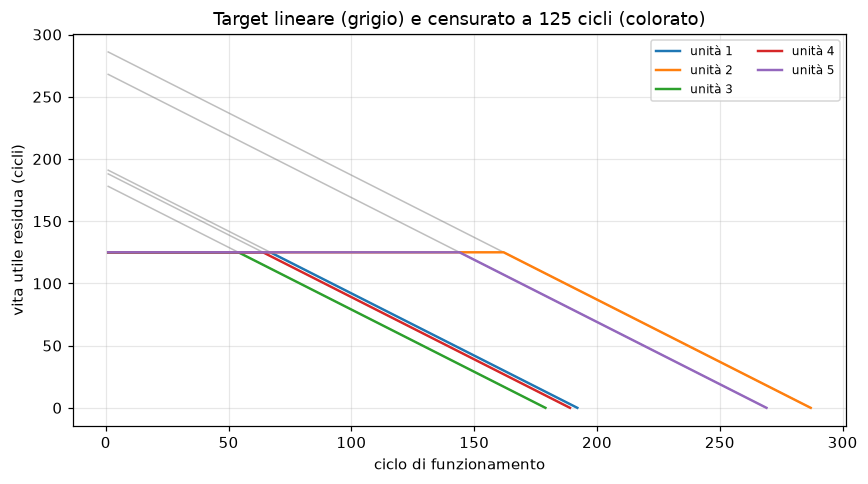

In [55]:
fig, ax = plt.subplots(figsize=(8, 4.5))

for unit, group in subset_traces.groupby("unit"):
    ax.plot(group["cycle"], group["rul"], linewidth=1, alpha=0.5,
            color="tab:gray")
    ax.plot(group["cycle"], group["rul"].clip(upper=RUL_CAP), linewidth=1.6,
            label=f"unità {unit}")

ax.set_xlabel("ciclo di funzionamento")
ax.set_ylabel("vita utile residua (cicli)")
ax.set_title(f"Target lineare (grigio) e censurato a {RUL_CAP} cicli (colorato)")
ax.legend(fontsize=8, ncol=2)

fig.tight_layout()
save_figure(fig, "target_censura")
plt.show()

## Tabella riassuntiva

La tabella raccoglie in una riga per sottoinsieme le grandezze usate per definire
il perimetro sperimentale. Viene salvata in `results/tables/` ed è l'artefatto
citabile di questa esplorazione.

In [56]:
rows = []
for name in SUBSET_ORDER:
    train_block = train_lengths[train_lengths["subset"] == name]
    test_block = test_lengths[test_lengths["subset"] == name]
    correlation_block = correlations[correlations["subset"] == name].dropna(subset=["pearson"])

    rows.append({
        "sottoinsieme": name,
        "motori_training": len(train_block),
        "righe_training": int(train_block["length"].sum()),
        "motori_test": len(test_block),
        "righe_test": int(test_block["length"].sum()),
        "durata_min": int(train_block["length"].min()),
        "durata_mediana": float(train_block["length"].median()),
        "durata_max": int(train_block["length"].max()),
        "durata_std": round(float(train_block["length"].std()), 1),
        "regimi": int((conditions["subset"] == name).sum()),
        "variabili_costanti": int(
            ((summary["subset"] == name) & summary["constant"]).sum()
        ),
        "max_abs_pearson": round(float(correlation_block["abs_pearson"].max()), 3),
        "in_perimetro": name in IN_SCOPE,
    })

overview = pd.DataFrame(rows)
path = TABLES_DIR / "esplorazione_sottoinsiemi.csv"
overview.to_csv(path, index=False)
print(f"tabella salvata: {path.relative_to(ROOT)}")
overview

tabella salvata: results/tables/esplorazione_sottoinsiemi.csv


,sottoinsieme,motori_training,righe_training,motori_test,righe_test,durata_min,durata_mediana,durata_max,durata_std,regimi,variabili_costanti,max_abs_pearson,in_perimetro
0,FD001,100,20631,100,13096,128,199.0,362,46.3,1,7,0.696,True
1,FD002,260,53759,259,33991,128,199.0,378,46.8,6,0,0.071,False
2,FD003,100,24720,100,16596,145,220.5,525,86.5,1,6,0.689,True
3,FD004,249,61249,248,41214,128,234.0,543,73.1,6,0,0.078,False


## Sintesi

I quattro sottoinsiemi si dispongono su due assi. Il numero di regimi di volo
separa FD001 e FD003, dove le letture di cicli diversi sono direttamente
confrontabili, da FD002 e FD004, dove la variabilità dei sensori è dominata dalla
condizione operativa e la correlazione marginale con il target si annulla. Il
numero di modi di guasto separa FD001 e FD002, con un solo meccanismo di
degradazione, da FD003 e FD004, dove ne coesistono due e le traiettorie sono più
lunghe e più disperse.

Il perimetro sperimentale del progetto comprende FD001 e FD003. La coppia tiene
fermo il regime di volo e fa variare il solo numero di modi di guasto, quindi
consente di applicare ai due sottoinsiemi un pre-processing identico e di
verificare se le conclusioni sul confronto tra modelli reggono su due
popolazioni diverse. FD002 e FD004 restano fuori: richiederebbero uno stadio di
normalizzazione dei sensori entro regime che sposterebbe il baricentro del lavoro
dalla comparazione tra modelli alla progettazione del pre-processing.

Due limiti vanno tenuti presenti nella lettura dei risultati. Il lavoro non
copre il caso a condizioni operative multiple, quindi le conclusioni valgono per
il regime singolo. La censura del target a 125 cicli è coerente con
l'informatività dei sensori su FD001 ma scarta su FD003 una parte di segnale
presente già prima della soglia.